# CIFAR-10: 2D graph/similarity-based μειωση διαστασης + spectral clustering

Σε αυτο το notebook:

1. Φορτωνω CIFAR-10 και παιρνω stratified subset (ισος αριθμος δειγματων ανα κλαση) για να ειναι εφικτες οι μεθοδοι manifold/graph.
2. Δουλευω σε **raw pixels** (χωρις HOG).
3. Κανω scaling στα features (StandardScaler) για να εχουν νοημα οι αποστασεις/γειτονιες.
4. Υπολογιζω 2D embedding με μεθοδους που βασιζονται:
   - σε φασματικη αναλυση γραφου (SpectralEmbedding)
   - σε ομοιοτητες/γειτονιες (LPP, LLE, Isomap, t-SNE, KernelPCA)
5. Παιρνω τα 2D δεδομενα και εφαρμοζω **Spectral Clustering**.
6. Οπτικοποιω τις ομαδες με διαφορετικα χρωματα.
7. Κανω εξερευνηση (grid) σε συνδιασμους μεθοδων και παραμετρων και κραταω metrics (ARI/NMI) για συγκριση.


Load libraries

In [10]:
from data_loader import load_cifar10
import matplotlib.pyplot as plt
import numpy as np
import time

from sklearn.preprocessing import StandardScaler

# 2D embeddings (graph/similarity based)
from sklearn.manifold import SpectralEmbedding, Isomap, LocallyLinearEmbedding, TSNE
from sklearn.decomposition import KernelPCA

# spectral clustering
from sklearn.cluster import SpectralClustering

from sklearn.neighbors import NearestNeighbors
import scipy.sparse as sp
from scipy.linalg import eigh
from lpproj import LocalityPreservingProjection

# evaluation (unsupervised agreement with true labels)
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

#Hog exploration
from skimage.feature import hog
from skimage.color import rgb2gray


## Load CIFAR-10

Φορτωνω το CIFAR-10 και κραταω train/test και label_names.


In [11]:
data = load_cifar10("cifar-10-batches-py")
X_train, y_train = data["x_train"], data["y_train"]
X_test, y_test   = data["x_test"], data["y_test"]
label_names = data["label_names"]

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)
print("Num classes:", len(label_names), label_names)


X_train: (50000, 32, 32, 3) y_train: (50000,)
X_test : (10000, 32, 32, 3) y_test : (10000,)
Num classes: 10 ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## Stratified subset (ισος αριθμος ανα κλαση)

Επειδη οι graph/manifold μεθοδοι δεν ειναι πρακτικες στο πληρες CIFAR-10, παιρνω stratified subset.
Ετσι μπορω να συγκρινω δικαια τις μεθοδους σε ιδια δεδομενα.


In [12]:
def select_stratified_subset_full(
    X_train, y_train,
    X_test, y_test,
    n_per_class,
    random_state=0
):
    """
    Create a single stratified subset from the *union* of (train + test),
    returning ONE dataset (X_sub, y_sub). No train/test split is produced.

    Parameters
    ----------
    X_train, y_train : arrays
        Original CIFAR-10 training split.
    X_test, y_test : arrays
        Original CIFAR-10 test split.
    n_per_class : int
        Number of samples to select per class from the combined pool.
    random_state : int
        RNG seed.

    Returns
    -------
    X_sub : np.ndarray
        Stratified subset (n_per_class * n_classes, ...).
    y_sub : np.ndarray
        Labels for evaluation/visualization.
    """
    num_classes = len(label_names)

    # combine all samples into one pool
    X_all = np.concatenate([X_train, X_test], axis=0)
    y_all = np.concatenate([y_train, y_test], axis=0)

    rng = np.random.default_rng(random_state)
    indices = []

    for c in range(num_classes):
        class_idxs = np.where(y_all == c)[0]
        if len(class_idxs) < n_per_class:
            raise ValueError(
                f"Not enough samples for class {c}: "
                f"have {len(class_idxs)}, requested {n_per_class}"
            )
        chosen = rng.choice(class_idxs, size=n_per_class, replace=False)
        indices.append(chosen)

    indices = np.concatenate(indices)
    rng.shuffle(indices)

    X_sub = X_all[indices]
    y_sub = y_all[indices]

    print("Subset shape:", X_sub.shape, "Labels shape:", y_sub.shape)
    return X_sub, y_sub


In [13]:
X_train_sub, y_train_sub = select_stratified_subset_full(
    X_train, y_train,
    X_test,  y_test,
    n_per_class=2000,
    random_state=0
)


Subset shape: (20000, 32, 32, 3) Labels shape: (20000,)


## Raw pixels -> vector + scaling

Επειδη δεν χρησιμοποιω HOG αυτη τη φορα, δουλευω σε raw pixels.
Κανω flatten καθε εικονα (32x32x3 -> 3072 features) και μετα StandardScaler ωστε οι αποστασεις/γειτονιες να ειναι πιο σταθερες.


In [14]:
# flatten raw pixels
X_flat = X_train_sub.reshape(X_train_sub.shape[0], -1).astype(np.float32)
print("Flat shape:", X_flat.shape)

# scaling
scaler = StandardScaler()
X_flat_s = scaler.fit_transform(X_flat)
print("Scaled flat shape:", X_flat_s.shape)


Flat shape: (20000, 3072)
Scaled flat shape: (20000, 3072)


## 2D Embeddings (graph/similarity-based)

Οριζω μια ενιαια συναρτηση που επιστρεφει 2D embedding για διαφορετικες μεθοδους:

- **spectral_embedding**: φασματικη αναλυση γραφου (Laplacian eigenmaps)
- **lpp (Locality Preserving Projections)**: γραμμικο graph embedding που διατηρει τοπικες γειτονιες (learned projection απο υψηλη διασταση σε 2D)
- **isomap**: geodesic αποστασεις σε kNN graph
- **lle**: τοπικη γραμμικη ανακατασκευη απο γειτονες
- **tsne**: similarity-based πιθανοτητες γειτονιας + optimization
- **kpca_rbf / kpca_poly**: kernel PCA (similarity via kernel)

Μετα το embedding, ομαδοποιω με spectral clustering στον 2D χωρο.


umap . hbd scan clustering?

In [15]:
def compute_embedding_2d(method, X, random_state=0, n_neighbors=15, tsne_perplexity=30):
    method = method.lower()

    if method == "spectral_embedding":
        model = SpectralEmbedding(
            n_components=2,
            affinity="nearest_neighbors",
            n_neighbors=n_neighbors,
            random_state=random_state
        )

    elif method == "isomap":
        model = Isomap(
            n_neighbors=n_neighbors,
            n_components=2
        )

    elif method == "lle":
        model = LocallyLinearEmbedding(
            n_neighbors=n_neighbors,
            n_components=2,
            method="standard",
            random_state=random_state
        )

    elif method == "tsne":
        model = TSNE(
            n_components=2,
            perplexity=tsne_perplexity,
            init="pca",
            learning_rate="auto",
            random_state=random_state
        )

    elif method == "kpca_rbf":
        model = KernelPCA(
            n_components=2,
            kernel="rbf",
            gamma=0.0061
        )

    elif method == "kpca_poly":
        model = KernelPCA(
            n_components=2,
            kernel="poly",
            degree=3,
            gamma=0.0061,
            coef0=1.0
        )
    elif method == "lpp":
        # LPP: Locality Preserving Projections (linear graph-based embedding)
        model = LocalityPreservingProjection(n_components=2)

    else:
        raise ValueError("Unknown method")

    t0 = time.perf_counter()
    Z2 = model.fit_transform(X)
    t = time.perf_counter() - t0
    return Z2, t


## Spectral clustering στα 2D δεδομενα

Μετα το 2D embedding, εφαρμοζω spectral clustering.
Η παραμετρος n_clusters μπορει να αλλαζει για εξερευνηση, αλλα ως baseline βαζω 10 (CIFAR-10).


In [16]:
def spectral_cluster_2d(Z2, n_clusters=10, n_neighbors=15, random_state=0):
    model = SpectralClustering(
        n_clusters=n_clusters,
        affinity="nearest_neighbors",
        n_neighbors=n_neighbors,
        assign_labels="kmeans",
        random_state=random_state
    )
    t0 = time.perf_counter()
    c = model.fit_predict(Z2)
    t = time.perf_counter() - t0
    return c, t


## Εξερευνηση συνδιασμων (embedding + παραμετροι + spectral clustering)

Τρεχω grid σε:
- embedding method
- n_neighbors (για graph-based μεθοδους)
- perplexity (μονο για t-SNE)
- n_clusters (για spectral clustering)

Κραταω:
- χρονο embedding
- χρονο clustering
- ARI / NMI (προαιρετικα, για να εχω αριθμητικη ενδειξη σχεσης με τα labels)


In [17]:
import scipy
print("SciPy version:", scipy.__version__)
# vale meta ksana 1.15.1

SciPy version: 1.13.1


In [18]:
# !conda install scipy=1.13.1

In [19]:
methods = ["spectral_embedding", "lpp", "isomap", "lle", "tsne", "kpca_rbf", "kpca_poly"]

neighbors_grid = [5, 10, 15]
clusters_grid  = [10]
tsne_perp_grid = [20, 30, 40]  # only for tsne

results = []

for method in methods:
    for nn in neighbors_grid:
        perp_list = tsne_perp_grid if method == "tsne" else [None]

        for perp in perp_list:
            Z2, t_emb = compute_embedding_2d(
                method,
                X_flat_s,
                random_state=0,
                n_neighbors=nn,
                tsne_perplexity=perp if perp is not None else 30
            )

            for k in clusters_grid:
                c, t_clu = spectral_cluster_2d(Z2, n_clusters=k, n_neighbors=nn, random_state=0)

                ari = adjusted_rand_score(y_train_sub, c)
                nmi = normalized_mutual_info_score(y_train_sub, c)

                results.append({
                    "method": method,
                    "n_neighbors": nn,
                    "tsne_perplexity": perp,
                    "n_clusters": k,
                    "embed_time_sec": t_emb,
                    "cluster_time_sec": t_clu,
                    "ARI": ari,
                    "NMI": nmi
                })

print("Num runs:", len(results))


/home/chpapadopoulos/anaconda3/envs/geoSpy/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/chpapadopoulos/anaconda3/envs/geoSpy/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/chpapadopoulos/anaconda3/envs/geoSpy/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/chpapadopoulos/anaconda3/envs/geoSpy/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/chpapadopoulos/anaconda3/envs/geoSpy/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:

Num runs: 27


## Εντοπισμος καλυτερου συνδιασμου

Ταξινομω τα αποτελεσματα (π.χ. με βαση NMI ή ARI) και βρισκω το top-1.
Μετα οπτικοποιω το 2D scatter χρωματισμενο με τα clusters.


In [20]:
# καλυτερο με βαση NMI
best = sorted(results, key=lambda d: d["NMI"], reverse=True)[0]
best


{'method': 'tsne',
 'n_neighbors': 5,
 'tsne_perplexity': 30,
 'n_clusters': 10,
 'embed_time_sec': 75.45776162401307,
 'cluster_time_sec': 144.26118366105948,
 'ARI': 0.05631899115529018,
 'NMI': np.float64(0.09167287133148269)}

In [ ]:
# ξανατρεχω το best για να εχω τα Z2/clusters για plot
best_method = best["method"]
best_nn     = best["n_neighbors"]
best_perp   = best["tsne_perplexity"]
best_k      = best["n_clusters"]

Z2_best, _ = compute_embedding_2d(
    best_method,
    X_flat_s,
    random_state=0,
    n_neighbors=best_nn,
    tsne_perplexity=best_perp if best_perp is not None else 30
)

clusters_best, _ = spectral_cluster_2d(
    Z2_best,
    n_clusters=best_k,
    n_neighbors=best_nn,
    random_state=0
)

print("BEST:", best)
print("Cluster counts:", np.bincount(clusters_best))


/home/chpapadopoulos/anaconda3/envs/geoSpy/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


BEST: {'method': 'tsne', 'n_neighbors': 5, 'tsne_perplexity': 30, 'n_clusters': 10, 'embed_time_sec': 75.45776162401307, 'cluster_time_sec': 144.26118366105948, 'ARI': 0.05631899115529018, 'NMI': np.float64(0.09167287133148269)}
Cluster counts: [6575 4550 6663 2160    7    6   15    6    6   12]


## Οπτικοποιηση: διαφορετικα χρωματα για τις ομαδες (clusters)

Αυτο ειναι το τελικο ζητουμενο plot: τα 2D δεδομενα μετα το embedding, χρωματισμενα με το αποτελεσμα του spectral clustering.


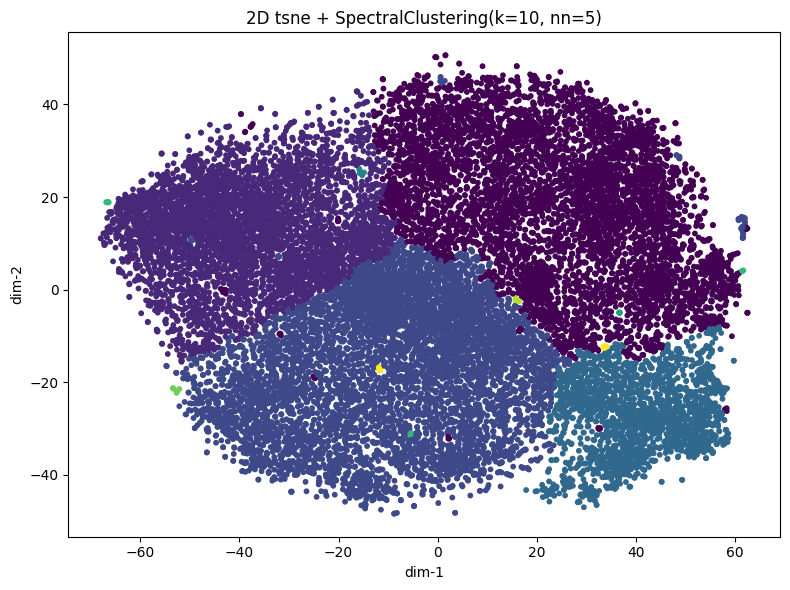

In [22]:
plt.figure(figsize=(8, 6))
plt.scatter(Z2_best[:, 0], Z2_best[:, 1], c=clusters_best, s=10)
plt.title(f"2D {best_method} + SpectralClustering(k={best_k}, nn={best_nn})")
plt.xlabel("dim-1")
plt.ylabel("dim-2")
plt.tight_layout()
plt.show()


## Συγκριση με true labels

Εδω δεν “εκπαιδευω” κατι με labels. Απλα βλεπω αν οπτικα τα clusters εχουν καποια αντιστοιχια με τις κλασεις του CIFAR-10.


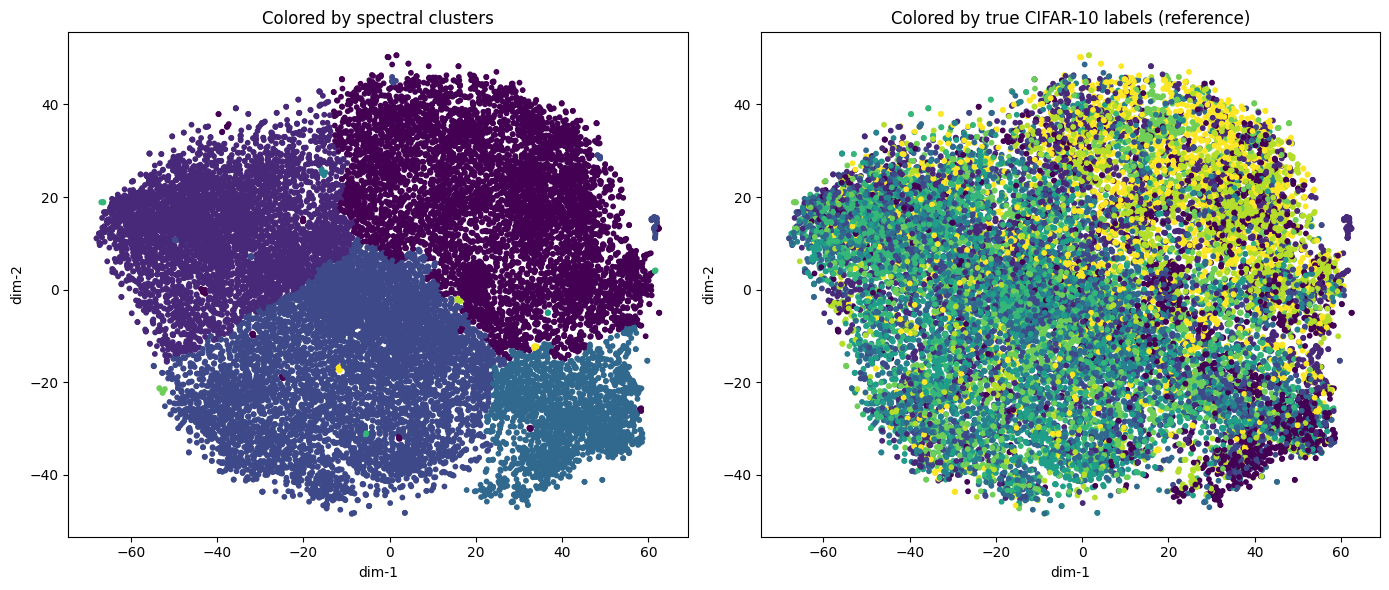

In [23]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(Z2_best[:, 0], Z2_best[:, 1], c=clusters_best, s=10)
plt.title("Colored by spectral clusters")
plt.xlabel("dim-1"); plt.ylabel("dim-2")

plt.subplot(1, 2, 2)
plt.scatter(Z2_best[:, 0], Z2_best[:, 1], c=y_train_sub, s=10)
plt.title("Colored by true CIFAR-10 labels (reference)")
plt.xlabel("dim-1"); plt.ylabel("dim-2")

plt.tight_layout()
plt.show()


## Top-3 αποτελεσματα για report

Εμφανιζω τα καλυτερα 3 runs, ωστε να τεκμηριωσω στην αναφορα οτι εκανα εξερευνηση διαφορετικων συνδιασμων (μεθοδοι + παραμετροι).


In [24]:
# top-3 με βαση NMI
topN = sorted(results, key=lambda d: d["NMI"], reverse=True)[:3]
for i, r in enumerate(topN, 1):
    print(i, r)


1 {'method': 'tsne', 'n_neighbors': 5, 'tsne_perplexity': 30, 'n_clusters': 10, 'embed_time_sec': 75.45776162401307, 'cluster_time_sec': 144.26118366105948, 'ARI': 0.05631899115529018, 'NMI': np.float64(0.09167287133148269)}
2 {'method': 'tsne', 'n_neighbors': 15, 'tsne_perplexity': 30, 'n_clusters': 10, 'embed_time_sec': 77.99231349199545, 'cluster_time_sec': 11.177554190042429, 'ARI': 0.04167168901140997, 'NMI': np.float64(0.08572413302557981)}
3 {'method': 'tsne', 'n_neighbors': 10, 'tsne_perplexity': 30, 'n_clusters': 10, 'embed_time_sec': 76.76981227297802, 'cluster_time_sec': 14.435831404989585, 'ARI': 0.04174104146597641, 'NMI': np.float64(0.08563657452115775)}


Σε raw pixels, οι αποστασεις δεν αποτυπωνουν καλα την “σημασιολογικη” ομοιοτητα, αρα τα clusters δεν ευθυγραμμιζονται με τις κλασεις.

Παρ’ ολα αυτα, το notebook υλοποιει ακριβως αυτο που ζηταει η εκφωνηση: 2D embedding (graph/similarity) -> spectral clustering -> visualization, και επιπλεον κανει exploration συνδιασμων.

-----------------------------------

## Update: Χρηση HOG features πριν απο το 2D embedding

Τα raw pixels στο CIFAR-10 δεν δινουν καλη μετρικη ομοιοτητας, οποτε τα graphs και τα similarity-based embeddings δεν σχηματιζουν καθαρη δομη.
Για να βελτιωσω τις ομοιοτητες μεταξυ δειγματων, εξαγω HOG descriptors (σε grayscale) και κανω StandardScaler. (Οπως και στις προηγουμενες εργασιες.)

Στη συνεχεια εφαρμοζω ακριβως την ιδια ροη:
2D embedding (graph/similarity-based) -> spectral clustering -> visualization.


In [25]:
def compute_hog_batch(X):
    hog_list = []
    for img in X:
        gray = rgb2gray(img)
        feats = hog(
            gray,
            orientations=9,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            block_norm="L2-Hys",
            visualize=False
        )
        hog_list.append(feats)
    return np.array(hog_list, dtype=np.float32)


In [26]:
print("Extracting HOG...")
t0 = time.perf_counter()
X_train_hog = compute_hog_batch(X_train_sub)
t_hog = time.perf_counter() - t0
print(f"HOG done in {t_hog:.2f} sec. Shape:", X_train_hog.shape)

scaler = StandardScaler()
X_train_feat = scaler.fit_transform(X_train_hog)
print("Scaled feature shape:", X_train_feat.shape)


Extracting HOG...


HOG done in 7.18 sec. Shape: (20000, 324)
Scaled feature shape: (20000, 324)


In [27]:
methods = ["spectral_embedding", "lpp", "isomap", "lle", "tsne", "kpca_rbf", "kpca_poly"]

neighbors_grid = [5, 10, 15]
clusters_grid  = [10]
tsne_perp_grid = [20, 30, 40]  # only for tsne

results = []

for method in methods:
    for nn in neighbors_grid:
        perp_list = tsne_perp_grid if method == "tsne" else [None]

        for perp in perp_list:
            Z2, t_emb = compute_embedding_2d(
                method,
                X_train_feat,
                random_state=0,
                n_neighbors=nn,
                tsne_perplexity=perp if perp is not None else 30
            )

            for k in clusters_grid:
                c, t_clu = spectral_cluster_2d(Z2, n_clusters=k, n_neighbors=nn, random_state=0)

                ari = adjusted_rand_score(y_train_sub, c)
                nmi = normalized_mutual_info_score(y_train_sub, c)

                results.append({
                    "method": method,
                    "n_neighbors": nn,
                    "tsne_perplexity": perp,
                    "n_clusters": k,
                    "embed_time_sec": t_emb,
                    "cluster_time_sec": t_clu,
                    "ARI": ari,
                    "NMI": nmi
                })

print("Num runs:", len(results))


/home/chpapadopoulos/anaconda3/envs/geoSpy/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/chpapadopoulos/anaconda3/envs/geoSpy/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/chpapadopoulos/anaconda3/envs/geoSpy/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/chpapadopoulos/anaconda3/envs/geoSpy/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/chpapadopoulos/anaconda3/envs/geoSpy/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:

Num runs: 27


In [28]:
# καλυτερο με βαση NMI
best = sorted(results, key=lambda d: d["NMI"], reverse=True)[0]
best


{'method': 'tsne',
 'n_neighbors': 15,
 'tsne_perplexity': 40,
 'n_clusters': 10,
 'embed_time_sec': 68.50349805597216,
 'cluster_time_sec': 10.642563760979101,
 'ARI': 0.08238799154068482,
 'NMI': np.float64(0.16549949273887138)}

BEST: {'method': 'tsne', 'n_neighbors': 15, 'tsne_perplexity': 40, 'n_clusters': 10, 'embed_time_sec': 68.50349805597216, 'cluster_time_sec': 10.642563760979101, 'ARI': 0.08238799154068482, 'NMI': np.float64(0.16549949273887138)}
Cluster counts: [1406 1919 2165 2224 1642 1904 1309 2736 2742 1953]


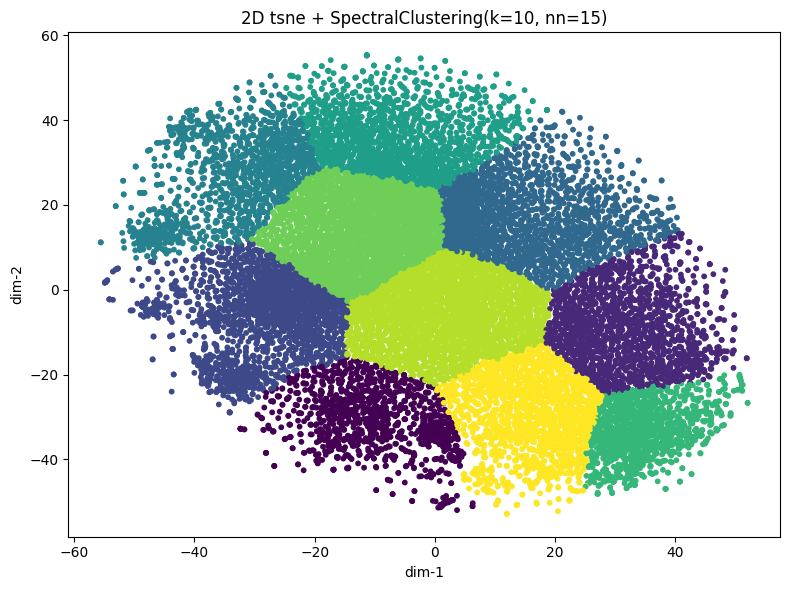

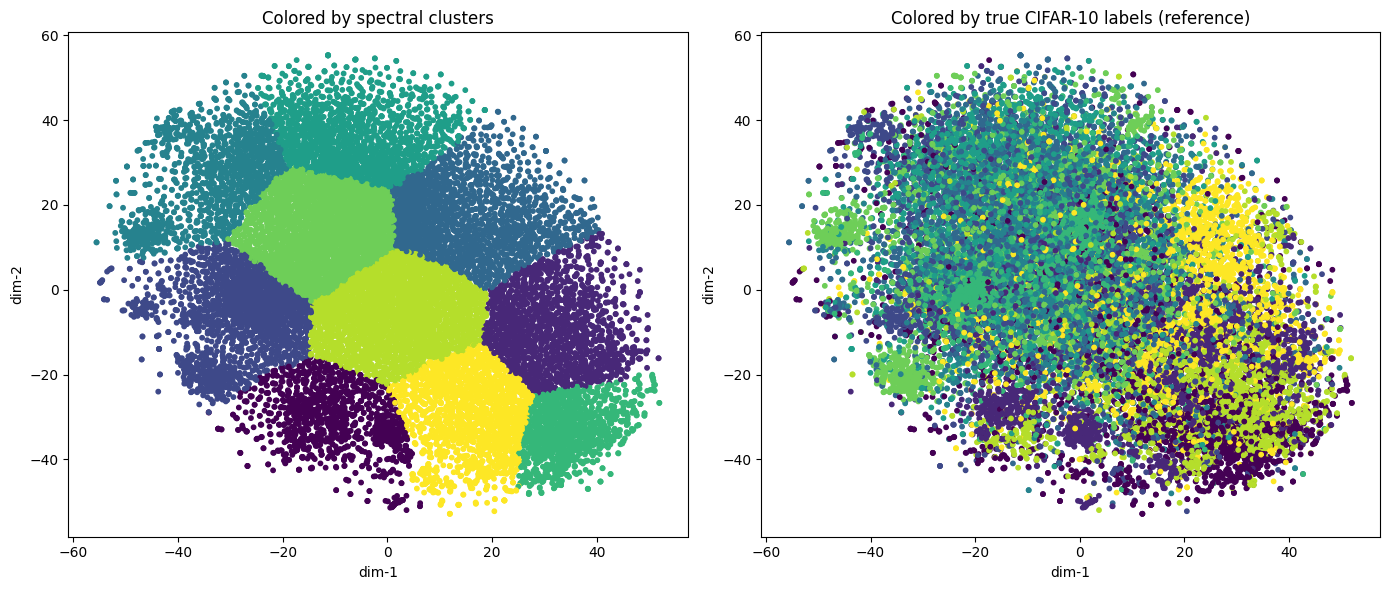

1 {'method': 'tsne', 'n_neighbors': 15, 'tsne_perplexity': 40, 'n_clusters': 10, 'embed_time_sec': 68.50349805597216, 'cluster_time_sec': 10.642563760979101, 'ARI': 0.08238799154068482, 'NMI': np.float64(0.16549949273887138)}
2 {'method': 'tsne', 'n_neighbors': 10, 'tsne_perplexity': 40, 'n_clusters': 10, 'embed_time_sec': 69.08633242896758, 'cluster_time_sec': 11.947673413902521, 'ARI': 0.08038754594034651, 'NMI': np.float64(0.16424500830147837)}
3 {'method': 'tsne', 'n_neighbors': 10, 'tsne_perplexity': 30, 'n_clusters': 10, 'embed_time_sec': 52.033951365039684, 'cluster_time_sec': 16.317219450953417, 'ARI': 0.08291079557438505, 'NMI': np.float64(0.15598764386706804)}


In [29]:
# ξανατρεχω το best για να εχω τα Z2/clusters για plot
best_method = best["method"]
best_nn     = best["n_neighbors"]
best_perp   = best["tsne_perplexity"]
best_k      = best["n_clusters"]

Z2_best, _ = compute_embedding_2d(
    best_method,
    X_train_feat,
    random_state=0,
    n_neighbors=best_nn,
    tsne_perplexity=best_perp if best_perp is not None else 30
)

clusters_best, _ = spectral_cluster_2d(
    Z2_best,
    n_clusters=best_k,
    n_neighbors=best_nn,
    random_state=0
)

print("BEST:", best)
print("Cluster counts:", np.bincount(clusters_best))

plt.figure(figsize=(8, 6))
plt.scatter(Z2_best[:, 0], Z2_best[:, 1], c=clusters_best, s=10)
plt.title(f"2D {best_method} + SpectralClustering(k={best_k}, nn={best_nn})")
plt.xlabel("dim-1")
plt.ylabel("dim-2")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(Z2_best[:, 0], Z2_best[:, 1], c=clusters_best, s=10)
plt.title("Colored by spectral clusters")
plt.xlabel("dim-1"); plt.ylabel("dim-2")

plt.subplot(1, 2, 2)
plt.scatter(Z2_best[:, 0], Z2_best[:, 1], c=y_train_sub, s=10)
plt.title("Colored by true CIFAR-10 labels (reference)")
plt.xlabel("dim-1"); plt.ylabel("dim-2")

plt.tight_layout()
plt.show()

# top-3 με βαση NMI
topN = sorted(results, key=lambda d: d["NMI"], reverse=True)[:3]
for i, r in enumerate(topN, 1):
    print(i, r)


Still not good :(